# Experiment 3: RGB-to-Grayscale CUDA Extension

Hand-written CUDA kernels convert RGB images to grayscale using ITU-R BT.601 weights (`0.299 R + 0.587 G + 0.114 B`), exposed to Python via a PyTorch C++/CUDA extension.

We measure:
- **Runtime** across image sizes (kernel only, tensors already on GPU)
- **Correctness** vs a PyTorch reference (`torch.allclose`)
- **Layout effect**: channel-last `(H, W, 3)` vs channel-first `(3, H, W)`

Installing ninja library to handle errors with the load fucntion of pytorch.cpp_extension

In [1]:
!pip install ninja

In [2]:
import os
from pathlib import Path

import pandas as pd
import torch

LAB_DIR = Path.cwd()

assert torch.cuda.is_available(), "CUDA is required for this experiment"
device = torch.device("cuda")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {torch.cuda.get_device_name(device)}")
print(f"Lab dir: {LAB_DIR}")

PyTorch: 2.8.0+cu128
Device: NVIDIA L4
Lab dir: /teamspace/studios/this_studio


## Load the CUDA extension

Sources: `rgb_grayscale.cu` (kernels) and `rgb_grayscale_ext.cpp` (PyTorch bindings).

In [3]:
from torch.utils.cpp_extension import load

rgb_ext = load(
    name="rgb_grayscale_ext",
    sources=[
        str(LAB_DIR / "rgb_grayscale_ext.cpp"),
        str(LAB_DIR / "rgb_grayscale.cu"),
    ],
    verbose=False,
)

print("Loaded:", [name for name in dir(rgb_ext) if not name.startswith("_")])

Loaded: ['rgb_to_grayscale_chw', 'rgb_to_grayscale_hwc']


## PyTorch reference implementations

The contiguity is handled by the input shape (channel-first/channel-last)

In [4]:
def rgb_to_grayscale_pytorch_hwc(image: torch.Tensor) -> torch.Tensor:
    """Input shape (H, W, 3), output (H, W)."""
    return 0.299 * image[..., 0] + 0.587 * image[..., 1] + 0.114 * image[..., 2]


def rgb_to_grayscale_pytorch_chw(image: torch.Tensor) -> torch.Tensor:
    """Input shape (3, H, W), output (H, W)."""
    return 0.299 * image[0] + 0.587 * image[1] + 0.114 * image[2]

## Correctness checks

Same random input for CUDA and PyTorch; compare with `torch.allclose`.

`torch.allclose` is a PyTorch function that checks whether two tensors are numerically the same within a tolerance. It returns `True` if every element of `a` and `b` is “close enough,” and `False` otherwise.

“Close enough” is controlled by `rtol` (relative tolerance) and `atol` (absolute tolerance): an element passes if `|a - b| ≤ atol + rtol × |b|`. It’s the standard way to compare floating-point results (e.g. CUDA vs PyTorch) without requiring bit-exact equality.

In [5]:
torch.manual_seed(42)
H, W = 480, 640

image_hwc = torch.rand(H, W, 3, device=device, dtype=torch.float32)
image_chw = image_hwc.permute(2, 0, 1).contiguous()

ref_hwc = rgb_to_grayscale_pytorch_hwc(image_hwc)
ref_chw = rgb_to_grayscale_pytorch_chw(image_chw)

out_cuda_hwc = rgb_ext.rgb_to_grayscale_hwc(image_hwc)
out_cuda_chw = rgb_ext.rgb_to_grayscale_chw(image_chw)

atol, rtol = 1e-6, 1e-5
hwc_ok = torch.allclose(out_cuda_hwc, ref_hwc, atol=atol, rtol=rtol)
chw_ok = torch.allclose(out_cuda_chw, ref_chw, atol=atol, rtol=rtol)
cross_layout_ok = torch.allclose(out_cuda_hwc, out_cuda_chw, atol=atol, rtol=rtol)

print(f"CUDA HWC vs PyTorch HWC: {hwc_ok}")
print(f"CUDA CHW vs PyTorch CHW: {chw_ok}")
print(f"CUDA HWC vs CUDA CHW (same data): {cross_layout_ok}")
if hwc_ok and chw_ok:
    print(f"Max abs diff HWC: {(out_cuda_hwc - ref_hwc).abs().max().item():.3e}")
    print(f"Max abs diff CHW: {(out_cuda_chw - ref_chw).abs().max().item():.3e}")

CUDA HWC vs PyTorch HWC: True
CUDA CHW vs PyTorch CHW: True
CUDA HWC vs CUDA CHW (same data): True
Max abs diff HWC: 1.192e-07
Max abs diff CHW: 1.192e-07


## Benchmark: kernel time vs image size and layout

Tensors are allocated on GPU **before** timing. We warm up, then average several timed runs using `torch.cuda.Event` (same idea as Experiment 1's `PyTorch_Kernel_ms`).

In [6]:
def benchmark_gpu(fn, warmup: int = 10, repeats: int = 50) -> float:
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(repeats):
        fn()
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / repeats


IMAGE_SIZES = [(256, 256), (512, 512), (1024, 1024), (2048, 2048), (4096, 4096)]
THREADS_PER_BLOCK = 256
WARMUP = 10
REPEATS = 50

rows = []
for height, width in IMAGE_SIZES:
    torch.manual_seed(0)
    image_hwc = torch.rand(height, width, 3, device=device, dtype=torch.float32)
    image_chw = image_hwc.permute(2, 0, 1).contiguous()

    num_pixels = height * width

    ms_pytorch_hwc = benchmark_gpu(
        lambda: rgb_to_grayscale_pytorch_hwc(image_hwc),
        warmup=WARMUP,
        repeats=REPEATS,
    )
    ms_pytorch_chw = benchmark_gpu(
        lambda: rgb_to_grayscale_pytorch_chw(image_chw),
        warmup=WARMUP,
        repeats=REPEATS,
    )
    ms_cuda_hwc = benchmark_gpu(
        lambda: rgb_ext.rgb_to_grayscale_hwc(image_hwc, THREADS_PER_BLOCK),
        warmup=WARMUP,
        repeats=REPEATS,
    )
    ms_cuda_chw = benchmark_gpu(
        lambda: rgb_ext.rgb_to_grayscale_chw(image_chw, THREADS_PER_BLOCK),
        warmup=WARMUP,
        repeats=REPEATS,
    )

    rows.append(
        {
            "H": height,
            "W": width,
            "num_pixels": num_pixels,
            "PyTorch_HWC_ms": ms_pytorch_hwc,
            "PyTorch_CHW_ms": ms_pytorch_chw,
            "CUDA_HWC_ms": ms_cuda_hwc,
            "CUDA_CHW_ms": ms_cuda_chw,
            "CUDA_CHW_over_HWC": ms_cuda_chw / ms_cuda_hwc,
            "PyTorch_CHW_over_HWC": ms_pytorch_chw / ms_pytorch_hwc,
        }
    )

results = pd.DataFrame(rows)
results

,H,W,num_pixels,PyTorch_HWC_ms,PyTorch_CHW_ms,CUDA_HWC_ms,CUDA_CHW_ms,CUDA_CHW_over_HWC,PyTorch_CHW_over_HWC
0,256,256,65536,0.099717,0.069530,0.015790,0.015811,1.001297,0.697268
1,512,512,262144,0.074342,0.069775,0.015647,0.015503,0.990838,0.938568
2,1024,1024,1048576,0.074504,0.068649,0.015360,0.015749,1.025333,0.921409
3,2048,2048,4194304,1.113948,0.598159,0.254996,0.254075,0.996386,0.536972
4,4096,4096,16777216,4.923576,3.468001,1.038561,1.034916,0.996490,0.704366


In [7]:
csv_path = LAB_DIR / "experiment_3_results.csv"
results.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")

Saved /teamspace/studios/this_studio/experiment_3_results.csv


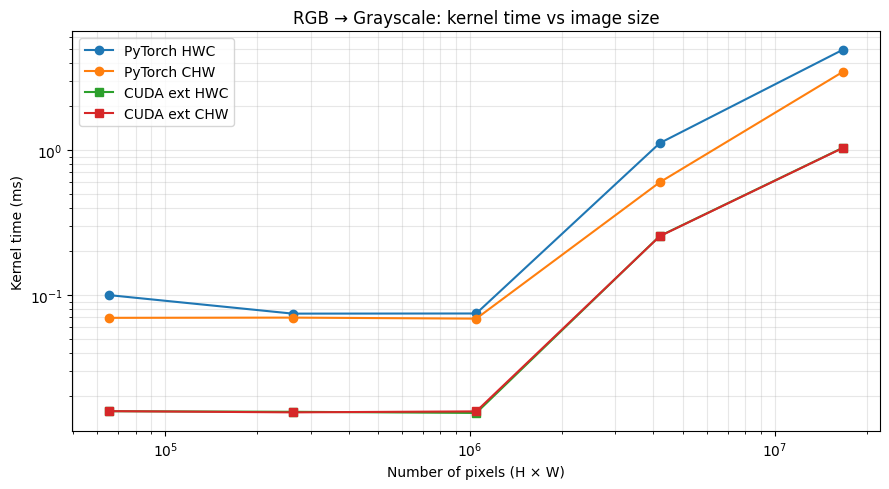

In [8]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 5))
    x = results["num_pixels"]
    ax.plot(x, results["PyTorch_HWC_ms"], marker="o", label="PyTorch HWC")
    ax.plot(x, results["PyTorch_CHW_ms"], marker="o", label="PyTorch CHW")
    ax.plot(x, results["CUDA_HWC_ms"], marker="s", label="CUDA ext HWC")
    ax.plot(x, results["CUDA_CHW_ms"], marker="s", label="CUDA ext CHW")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of pixels (H × W)")
    ax.set_ylabel("Kernel time (ms)")
    ax.set_title("RGB → Grayscale: kernel time vs image size")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed; skipping plot")

`TORCH_CHECK` is a PyTorch C++ macro that validates a condition before your extension continues. If the check passes, execution moves on; if it fails, PyTorch raises a Python `RuntimeError` with the message you provide.

Extension authors use it at the Python/C++ boundary to reject bad inputs—wrong device, dtype, shape, or memory layout—before calling `data_ptr()` or launching a CUDA kernel, so failures show up as clear errors instead of crashes or silent wrong results.

## Observations

### Correctness
- CUDA HWC and CHW outputs matched with PyTorch references within `atol=1.192e-07<1e-6` .
- Both layouts should produce the same grayscale image when fed the same underlying pixels (value check was true!)

### Small images (256²–1024²): launch overhead dominates CUDA time
- **`CUDA_HWC_ms` / `CUDA_CHW_ms`** stay ~**0.015–0.016 ms** while pixels grow **16×** (65K → 1M).
- Same pattern as Experiment 1 at small N: fixed **kernel launch + sync** cost, not real throughput.
- **Takeaway:** Below ~1M pixels, your custom kernel timing mostly measures overhead, not memory bandwidth.

---

### Large images (2048², 4096²): work scales with pixel count
- **4096²** vs **2048²** ≈ **4×** more pixels → CUDA time ≈ **4×** (0.255 → 1.04 ms).
- Op is **memory-bound**: ~3 float reads + 1 float write per pixel.
- **Takeaway:** Only at large H×W does the benchmark reflect real GPU work.

---

### Custom CUDA vs PyTorch
| Size | CUDA (≈) | PyTorch HWC | PyTorch CHW | CUDA speedup vs PyTorch HWC |
|------|----------|-------------|-------------|------------------------------|
| 256² | 0.016 ms | 0.100 ms | 0.070 ms | ~6× |
| 4096² | 1.04 ms | 4.92 ms | 3.47 ms | ~4.7× |

- Custom extension is **much faster** than the simple PyTorch weighted sum — expected: naive Python-side indexing vs a tight CUDA kernel.
- PyTorch is still highly optimized; your gap may shrink if you compare to `torch.nn.functional.rgb_to_grayscale` or fused ops.

---

### HWC vs CHW — surprising result for *your* CUDA kernel
- **`CUDA_CHW_over_HWC`** ≈ **1.0** at every size (0.99–1.03) → **no meaningful layout win** for your hand-written kernels.
- **Hypothesis to explore:**  
  - HWC: threads stride by 3 (weaker coalescing on first load), but R/G/B are **local** (`+0,+1,+2`).  
  - CHW: R loads coalesce across threads, but G/B are **H×W strides apart** per thread.  
  - For this simple 3-load kernel, those effects **cancel** on your GPU.
- **Contrast with PyTorch:** **`PyTorch_CHW_over_HWC`** is **0.70–0.54** on smaller/large sizes → PyTorch’s CHW path is faster; their kernels exploit layout better than yours.

---

### PyTorch HWC spike at 2048²
- **2048²:** PyTorch HWC **1.11 ms** vs CHW **0.60 ms** (~2×) — much larger than at other sizes.
- Worth a **second run** or higher `REPEATS` to rule out noise; could also be dtype/dispatch/kernel choice.
- **Note in write-up:** treat as “possible outlier until confirmed.”

---

### What you timed (and didn’t)
- **Included:** kernel + op on **GPU-resident** tensors (fair vs Experiment 1 `PyTorch_Kernel_ms`).
- **Excluded:** H2D/D2H, `permute().contiguous()`, first-time extension compile.
- **`permute().contiguous()` for CHW** happens **before** timing — layout conversion cost is not in these numbers.

---

### One-line summary
> Small images: CUDA time is flat (~0.015 ms) — launch-bound. Large images: CUDA scales linearly and beats naive PyTorch ~4–5×. Layout barely affects your CUDA kernel, but PyTorch favors CHW.

